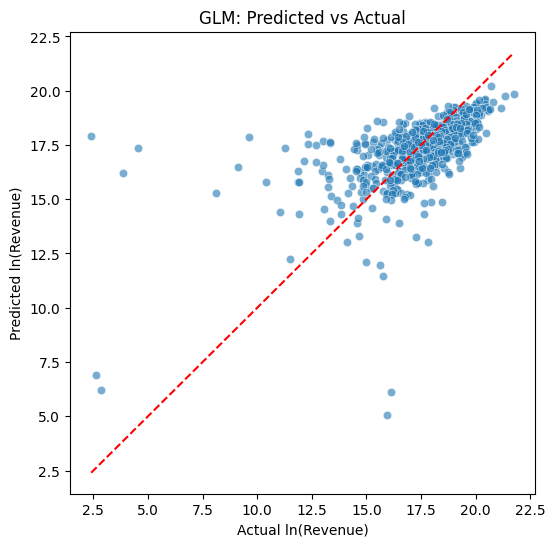

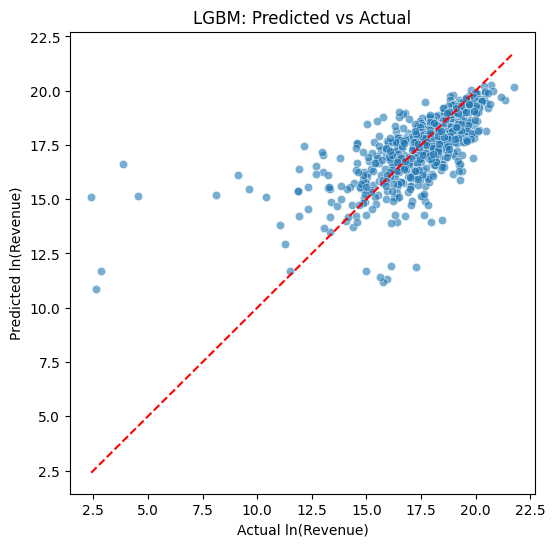

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from _load_predictions import load_predict_parquet

df = load_predict_parquet()

def plot_pred_vs_actual(df, pred_col, actual_col='ln_revenue', model_name='Model'):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df[actual_col], y=df[pred_col], alpha=0.6)
    plt.plot([df[actual_col].min(), df[actual_col].max()],
             [df[actual_col].min(), df[actual_col].max()],
             'r--')
    plt.xlabel("Actual ln(Revenue)")
    plt.ylabel("Predicted ln(Revenue)")
    plt.title(f"{model_name}: Predicted vs Actual")
    plt.show()

plot_pred_vs_actual(df, 'pred_glm', model_name='GLM')
plot_pred_vs_actual(df, 'pred_lgbm', model_name='LGBM')


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load saved SHAP values
shap_values = np.load("/home/gmurp/project/d100project/evaluation/shap_values_glm.npy")  # shape: (n_samples, n_features)

feature_names = ["budget", "runtime", "year", "genres_Drama", "genres_Comedy", "genres_Thriller", "genres_Action", "genres_Romance", "genres_Adventure", "genres_Crime", "genres_Science Fiction", "genres_Horror", "genres_Family", "genres_Fantasy", "genres_Mystery", "genres_Animation", "genres_History", "genres_Music", "genres_War", "genres_Documentary", "genres_Western", "genres_Foreign", "genres_TV Movie", "original_language", "n_production_companies", "n_production_countries", "n_spoken_languages"]
shap_df = pd.DataFrame(shap_values, columns=feature_names)

# Compute mean absolute SHAP values
shap_abs_mean = shap_df.abs().mean(axis=0)

# Select top 10 features
top_features = shap_abs_mean.sort_values(ascending=False).head(10)

# Plot inline in the notebook
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 Features by Mean Absolute SHAP Value")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()



ValueError: Shape of passed values is (682, 26), indices imply (682, 27)

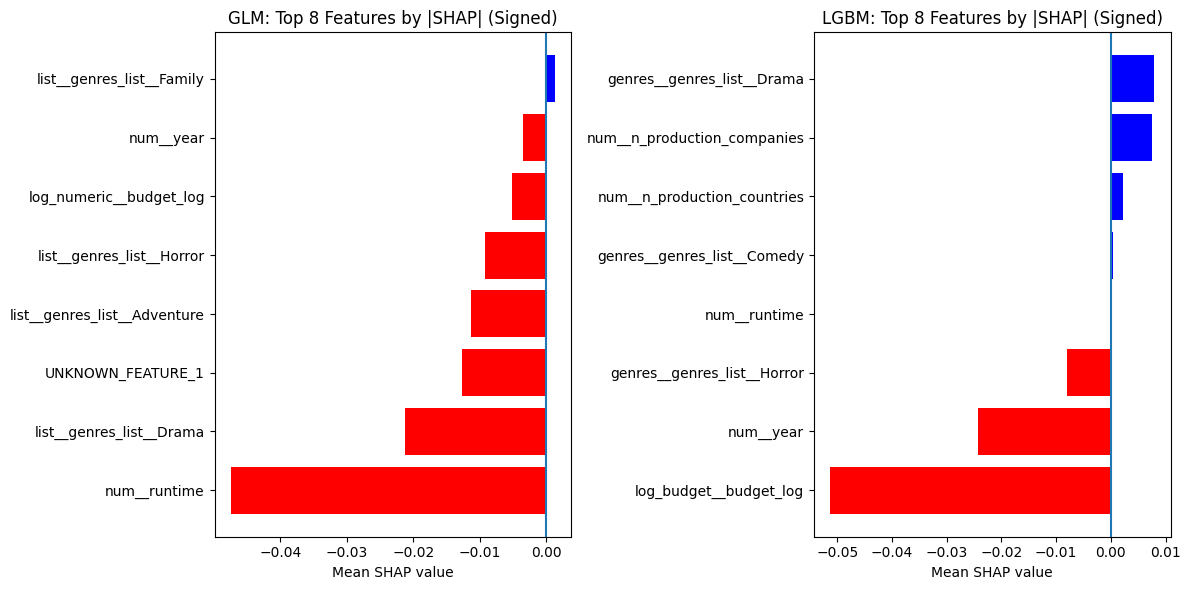

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_prepare_abs_select_signed(path, top_n=8):
    # Load SHAP values
    data = np.load(path, allow_pickle=True).item()
    shap_vals = data["shap_values"]
    feature_names = list(data["feature_names"])

    # Pad feature names if needed
    if shap_vals.shape[1] > len(feature_names):
        feature_names += [f"UNKNOWN_FEATURE_{i}" for i in range(shap_vals.shape[1] - len(feature_names))]

    shap_df = pd.DataFrame(shap_vals, columns=feature_names)

    # Compute mean absolute and mean signed
    mean_abs = shap_df.abs().mean()
    mean_signed = shap_df.mean()

    # Select top N by absolute SHAP
    top_features = mean_abs.nlargest(top_n).index
    top_signed = mean_signed.loc[top_features]

    # Sort for plotting (smallest signed at bottom, largest at top)
    top_signed_sorted = top_signed.sort_values()

    # Colors
    colors = ['red' if v < 0 else 'blue' for v in top_signed_sorted]

    return top_signed_sorted, colors

# Load GLM and LGBM
glm_vals, glm_colors = load_prepare_abs_select_signed("shap_values_glm_with_names.npy", 8)
lgbm_vals, lgbm_colors = load_prepare_abs_select_signed("shap_values_lgbm_with_names.npy", 8)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh(glm_vals.index, glm_vals.values, color=glm_colors)
plt.axvline(0)
plt.title("GLM: Top 8 Features by |SHAP| (Signed)")
plt.xlabel("Mean SHAP value")

plt.subplot(1, 2, 2)
plt.barh(lgbm_vals.index, lgbm_vals.values, color=lgbm_colors)
plt.axvline(0)
plt.title("LGBM: Top 8 Features by |SHAP| (Signed)")
plt.xlabel("Mean SHAP value")

plt.tight_layout()
plt.show()
